# Customer Lifetime Value Model
- Justin Wall, Senior Data Scientist, Ridgeline Outfitters

---
## Questions to answer
1. Some way to estimate future value per customer (or per segment) — not just "what have they spent so far," but what we should expect over the next 12 months.
2. Confidence ranges, not just point estimates — I don't want to walk into a budget meeting with a number that turns out to be 3x off in practice.
3. A clear way to compare that future value against what we're paying to acquire or retain people, so we can actually set sane spend limits.

## Load Data

In [2]:
import pandas as pd

df = pd.read_csv('../data/ridgeline_outfitters_transactions.csv', parse_dates=['transaction_date'])

print(df.shape)
print('-------------------------------')
print(df.dtypes)
print('-------------------------------')
print(df.head())
print('-------------------------------')
print(df.describe())

(5282, 3)
-------------------------------
customer_id                    str
transaction_date    datetime64[us]
order_value                float64
dtype: object
-------------------------------
  customer_id transaction_date  order_value
0    RO-10000       2023-01-02       261.92
1    RO-10000       2023-04-08       103.40
2    RO-10000       2023-08-27        46.61
3    RO-10000       2023-11-14        37.09
4    RO-10000       2024-05-11        44.66
-------------------------------
                 transaction_date  order_value
count                        5282  5282.000000
mean   2023-08-11 04:36:59.159409   181.120015
min           2022-01-01 00:00:00    15.000000
25%           2023-01-05 00:00:00    67.685000
50%           2023-08-03 00:00:00   132.590000
75%           2024-03-30 00:00:00   244.315000
max           2024-12-31 00:00:00   800.000000
std                           NaN   158.015204


In [3]:
# Transaction date range
print(f"Date range: {df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}")

# Customer counts
print(f"Unique customers: {df['customer_id'].nunique()}")
print(f"Total transactions: {len(df)}")

# Order value
print(f"\nOrder value summary:")
print(df['order_value'].describe().round(2))

# Transactions per customer
txn_per_customer = df.groupby('customer_id').size()
print(f"\nTransactions per customer:")
print(txn_per_customer.describe().round(2))

Date range: 2022-01-01 to 2024-12-31
Unique customers: 1000
Total transactions: 5282

Order value summary:
count    5282.00
mean      181.12
std       158.02
min        15.00
25%        67.68
50%       132.59
75%       244.32
max       800.00
Name: order_value, dtype: float64

Transactions per customer:
count    1000.00
mean        5.28
std         6.80
min         1.00
25%         1.00
50%         3.00
75%         6.00
max        28.00
dtype: float64


In [4]:
from lifetimes.utils import summary_data_from_transaction_data

CALIBRATION_END = pd.Timestamp('2024-06-30')

calib_df = df[df['transaction_date'] <= CALIBRATION_END]

rfm = summary_data_from_transaction_data(
    calib_df,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='order_value',
    observation_period_end=CALIBRATION_END,
    freq='D'
)

print(rfm.shape)
print(rfm.head(10))
print(rfm.describe().round(2))

(1000, 4)
             frequency  recency      T  monetary_value
customer_id                                           
RO-10000           4.0    495.0  545.0       57.940000
RO-10001           0.0      0.0  583.0        0.000000
RO-10002          16.0    627.0  661.0      136.392500
RO-10003           1.0    145.0  425.0      627.980000
RO-10004           0.0      0.0  742.0        0.000000
RO-10005           3.0    191.0  376.0       15.613333
RO-10006           4.0    678.0  700.0      261.672500
RO-10007           3.0    330.0  545.0      486.346667
RO-10008           0.0      0.0  803.0        0.000000
RO-10009           5.0    688.0  696.0      544.314000
       frequency  recency        T  monetary_value
count    1000.00  1000.00  1000.00         1000.00
mean        3.41   261.63   631.71           95.27
std         5.35   285.52   156.64          119.79
min         0.00     0.00   372.00            0.00
25%         0.00     0.00   493.75            0.00
50%         1.00   188.5

In [5]:
print(f"Customers with only 1 purchase (frequency=0): {(rfm['frequency'] == 0).sum()}")
print(f"Customers with repeat purchases:              {(rfm['frequency'] > 0).sum()}")
print(f"Average repeat purchase monetary value:       ${rfm[rfm['frequency'] > 0]['monetary_value'].mean():.2f}")
print(f"Max customer age in dataset (days):           {rfm['T'].max():.0f}")

Customers with only 1 purchase (frequency=0): 462
Customers with repeat purchases:              538
Average repeat purchase monetary value:       $177.08
Max customer age in dataset (days):           911


***
### **Notes**:
3 years of daily data, 1000 customers, 5,282 transactions. Only 3 columns, keeping it simple.

Breakout above for single purchasers vs repeat purchasers

- Train Start Date: 2022-01-01
- Train End Date: 2024-06-30
- Test Start Date: 2024-07-01
- Test End Date: 2024-12-31
***

## Data Alignment

In [6]:
# Define observation date and split
import pandas as pd

CALIBRATION_END = pd.Timestamp('2024-06-30')

In [7]:
# Split raw data
calib_df = df[df['transaction_date'] <= CALIBRATION_END]
holdout_df = df[df['transaction_date'] > CALIBRATION_END]

print(f"Calibration transactions: {len(calib_df)}")
print(f"Holdout transactions:     {len(holdout_df)}")
print(f"Customers in holdout:     {holdout_df['customer_id'].nunique()}")

Calibration transactions: 4409
Holdout transactions:     873
Customers in holdout:     316


In [8]:
# RFM Summary Table
from lifetimes.utils import summary_data_from_transaction_data

rfm = summary_data_from_transaction_data(
    calib_df,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='order_value',
    observation_period_end=CALIBRATION_END,
    freq='D'
)

print(rfm.shape)
print(rfm.head(10))
print(rfm.describe().round(2))

(1000, 4)
             frequency  recency      T  monetary_value
customer_id                                           
RO-10000           4.0    495.0  545.0       57.940000
RO-10001           0.0      0.0  583.0        0.000000
RO-10002          16.0    627.0  661.0      136.392500
RO-10003           1.0    145.0  425.0      627.980000
RO-10004           0.0      0.0  742.0        0.000000
RO-10005           3.0    191.0  376.0       15.613333
RO-10006           4.0    678.0  700.0      261.672500
RO-10007           3.0    330.0  545.0      486.346667
RO-10008           0.0      0.0  803.0        0.000000
RO-10009           5.0    688.0  696.0      544.314000
       frequency  recency        T  monetary_value
count    1000.00  1000.00  1000.00         1000.00
mean        3.41   261.63   631.71           95.27
std         5.35   285.52   156.64          119.79
min         0.00     0.00   372.00            0.00
25%         0.00     0.00   493.75            0.00
50%         1.00   188.5

In [9]:
# Holdout dataset summary table
from lifetimes.utils import calibration_and_holdout_data

rfm_ch = calibration_and_holdout_data(
    df,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='order_value',
    calibration_period_end=CALIBRATION_END,
    observation_period_end=pd.Timestamp('2024-12-31'),
    freq='D'
)

print(rfm_ch.shape)
print(rfm_ch.head(10))

(1000, 7)
             frequency_cal  recency_cal  T_cal  monetary_value_cal  \
customer_id                                                          
RO-10000               4.0        495.0  545.0           57.940000   
RO-10001               0.0          0.0  583.0            0.000000   
RO-10002              16.0        627.0  661.0          136.392500   
RO-10003               1.0        145.0  425.0          627.980000   
RO-10004               0.0          0.0  742.0            0.000000   
RO-10005               3.0        191.0  376.0           15.613333   
RO-10006               4.0        678.0  700.0          261.672500   
RO-10007               3.0        330.0  545.0          486.346667   
RO-10008               0.0          0.0  803.0            0.000000   
RO-10009               5.0        688.0  696.0          544.314000   

             frequency_holdout  monetary_value_holdout  duration_holdout  
customer_id                                                               

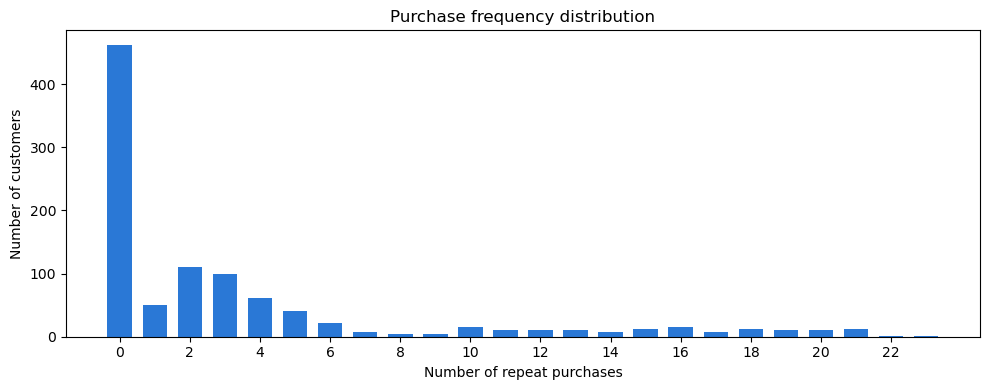

In [10]:
# Purchase Frequency Histogram
import matplotlib.pyplot as plt

freq_counts = rfm['frequency'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(freq_counts.index, freq_counts.values, color='#2a78d6', width=0.7)
ax.set_xlabel('Number of repeat purchases')
ax.set_ylabel('Number of customers')
ax.set_title('Purchase frequency distribution')
ax.set_xticks(range(0, int(rfm['frequency'].max()) + 1, 2))
plt.tight_layout()
plt.show()

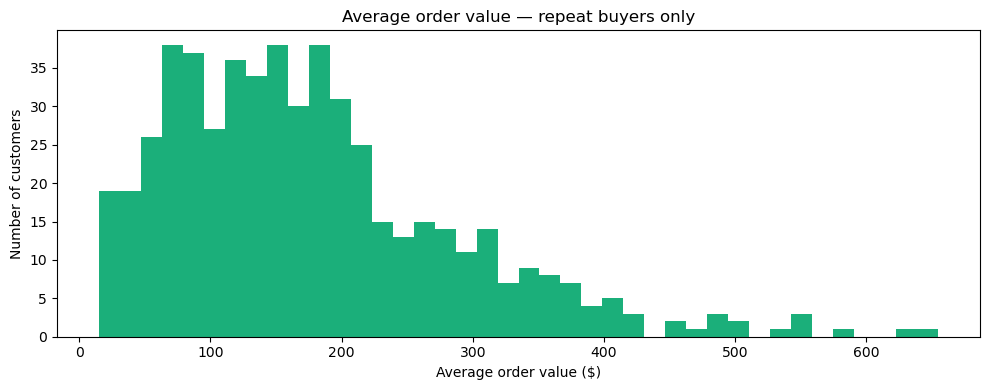

In [11]:
# Average Order Value Distribution for repeat buyers only

repeat_buyers = rfm[rfm['frequency'] > 0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(repeat_buyers['monetary_value'], bins=40, color='#1baf7a', edgecolor='none')
ax.set_xlabel('Average order value ($)')
ax.set_ylabel('Number of customers')
ax.set_title('Average order value — repeat buyers only')
plt.tight_layout()
plt.show()

In [12]:
# RFM Summary Tables
def segment_label(freq):
    if freq == 0:
        return 'One-time'
    elif freq <= 2:
        return 'Low (1-2 repeats)'
    elif freq <= 6:
        return 'Mid (3-6 repeats)'
    else:
        return 'High (7+ repeats)'

rfm['segment'] = rfm['frequency'].apply(segment_label)

summary = rfm.groupby('segment').agg(
    customers=('frequency', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_order_value=('monetary_value', 'mean')
).round(1)

summary['avg_order_value'] = summary['avg_order_value'].apply(lambda x: f"${x:.2f}")
summary['avg_recency_days'] = summary['avg_recency_days'].apply(lambda x: f"{x:.0f} days")

order = ['One-time', 'Low (1-2 repeats)', 'Mid (3-6 repeats)', 'High (7+ repeats)']
summary = summary.reindex(order)

print(summary.to_string())

                   customers avg_recency_days avg_order_value
segment                                                      
One-time                 462           0 days           $0.00
Low (1-2 repeats)        161         295 days         $163.10
Mid (3-6 repeats)        224         526 days         $176.10
High (7+ repeats)        153         630 days         $193.20


***
### **Notes**:
1. Mostly 1-time purchasers, huge tail for frequency
2. Frequency bumped around $100 to $200, skewed right
3. AOV & recency increasing for high quantity purchasers
***

## Modeling & Validation

Options for methodology
- Historical Averages & RFM Heuristics
    - Quick and easy, but not predictive
- Pareto/NBD Model
    - Models alive vs dead well, but outclassed by BG/NBD
- BG/NBD + Gamma-Gamma
    - Probabilistic to show uncertainty, fully interpretable, but no features
- Survival Analysis
    - Works for subscription businesses, but need specific churn event to work
- ML Regression
    - Best raw prediction accuracy, fast, uses features, but hard to explain & no uncertainty
- Deep Learning
    - Captures complex patterns, but no interpretability

Options for libraries
- Lifetimes
    - Simple syntax, but could run into issues since unmaintained & MLE instead of MCMC
- PYMC-Marketing
    - Actively maintained Bayesian framework, but will lack flexibility for deep dives
- Custom PYMC
    - Most flexible, but most of this is already baked in PYMC-Marketing

### Lifetimes

In [13]:
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter

# Rebuild RFM in weeks instead of days
rfm_weeks = summary_data_from_transaction_data(
    calib_df,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='order_value',
    observation_period_end=CALIBRATION_END,
    freq='W'
)

bgf = BetaGeoFitter(penalizer_coef=0.1)
bgf.fit(
    rfm_weeks['frequency'],
    rfm_weeks['recency'],
    rfm_weeks['T'],
    initial_params=[0.5, 5.0, 0.5, 5.0]  # r, alpha, a, b
)
print(bgf.summary)

                coef  se(coef)  lower 95% bound  upper 95% bound
r       3.310886e-01       NaN              NaN              NaN
alpha   8.846238e+00       NaN              NaN              NaN
a      1.645438e-287       NaN              NaN              NaN
b       8.584339e-06       NaN              NaN              NaN


c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\tracer.py:93: RuntimeWarning: divide by zero encountered in log
  return f_raw(*args, **kwargs)
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\numpy\numpy_vjps.py:166: RuntimeWarning: divide by zero encountered in divide
  defvjp(anp.log, lambda ans, x: lambda g: g / x)
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\numpy\numpy_vjps.py:81: RuntimeWarning: invalid value encountered in multiply
  lambda ans, x, y: unbroadcast_f(x, lambda g: y * g),
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\numpy\numpy_vjps.py:163: RuntimeWarning: invalid value encountered in multiply
  defvjp(anp.exp, lambda ans, x: lambda g: ans * g)
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\tracer.py:93: RuntimeWarning: divide by zero encountered in log
  return f_raw(*args, **kwargs)
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\nu

In [14]:
'''
TECHNICAL NOTE: Lifetimes BetaGeoFitter failed to converge with both default and custom initial parameters. The dropout parameters (a, b) collapsed to
effectively zero regardless of penalizer or starting values, indicating a degenerate likelihood surface rather than a tuning problem.
Switching to PyMC-Marketing for full Bayesian estimation with priors that prevent parameter collapse.

Rebuilt RFM in weeks (vs days), days caused optimizer failure in lifetimes, weeks resolved scaling issues in PyMC-Marketing
'''

'\nTECHNICAL NOTE: Lifetimes BetaGeoFitter failed to converge with both default and custom initial parameters. The dropout parameters (a, b) collapsed to\neffectively zero regardless of penalizer or starting values, indicating a degenerate likelihood surface rather than a tuning problem.\nSwitching to PyMC-Marketing for full Bayesian estimation with priors that prevent parameter collapse.\n\nRebuilt RFM in weeks (vs days), days caused optimizer failure in lifetimes, weeks resolved scaling issues in PyMC-Marketing\n'

### PYMC-Marketing

In [15]:
from pymc_marketing.clv import BetaGeoModel
import pandas as pd

# PyMC-Marketing wants a specific column structure
rfm_pymc = rfm_weeks.copy().reset_index()
rfm_pymc = rfm_pymc.rename(columns={
    'customer_id': 'customer_id',
    'frequency': 'frequency',
    'recency': 'recency',
    'T': 'T',
    'monetary_value': 'monetary_value'
})

print(rfm_pymc.head())
print(rfm_pymc.shape)

  customer_id  frequency  recency      T  monetary_value
0    RO-10000        4.0     70.0   77.0         57.9400
1    RO-10001        0.0      0.0   83.0          0.0000
2    RO-10002       16.0     90.0   94.0        136.3925
3    RO-10003        1.0     20.0   60.0        627.9800
4    RO-10004        0.0      0.0  106.0          0.0000
(1000, 5)


In [16]:
bgm = BetaGeoModel(data=rfm_pymc)
bgm.fit()

Initializing NUTS using jitter+adapt_diag...
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi_dropout, kappa_dropout, r]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 27 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> fit_data

In [17]:
bgm.fit_summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,9.717,0.798,8.229,11.192,0.018,0.012,1940.0,2373.0,1.0
phi_dropout,0.002,0.002,0.000,0.006,0.000,0.000,2262.0,1477.0,1.0
kappa_dropout,4.672,41.621,1.000,8.937,0.666,14.612,3123.0,2041.0,1.0
r,0.363,0.022,0.322,0.405,0.001,0.000,1995.0,2715.0,1.0
a,0.006,0.017,0.000,0.016,0.000,0.003,2600.0,1657.0,1.0
b,4.666,41.608,0.994,8.936,0.666,14.609,3134.0,2037.0,1.0


In [18]:
from pymc_marketing.clv import GammaGammaModel

# Filter to repeat buyers only
repeat_buyers_pymc = rfm_pymc[rfm_pymc['frequency'] > 0]

ggm = GammaGammaModel(data=repeat_buyers_pymc)
ggm.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p, q, v]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 24 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> fit_data

In [19]:
ggm.fit_summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,1.145,0.145,0.888,1.422,0.005,0.003,972.0,1255.0,1.01
q,6.491,1.056,4.696,8.478,0.034,0.034,1044.0,1063.0,1.01
v,905.279,272.053,480.576,1392.518,9.257,10.560,915.0,1012.0,1.01


In [20]:
'''
TECHNICAL NOTE: Lifetimes GammaGammaFitter failed to converge with both default and custom initial parameters.
The dropout parameters (p, q) collapsed to
effectively zero regardless of penalizer or starting values, indicating a degenerate likelihood surface rather than
a tuning problem.
'''

'\nTECHNICAL NOTE: Lifetimes GammaGammaFitter failed to converge with both default and custom initial parameters.\nThe dropout parameters (p, q) collapsed to\neffectively zero regardless of penalizer or starting values, indicating a degenerate likelihood surface rather than\na tuning problem.\n'

In [21]:
repeat_buyers_pymc = rfm_pymc[rfm_pymc['frequency'] > 0]

print(repeat_buyers_pymc['monetary_value'].describe().round(2))
print(f"\nSkewness: {repeat_buyers_pymc['monetary_value'].skew():.2f}")
print(f"Customers in fit: {len(repeat_buyers_pymc)}")

count    538.00
mean     177.08
std      110.36
min       15.00
25%       93.34
50%      156.90
75%      228.34
max      654.78
Name: monetary_value, dtype: float64

Skewness: 1.14
Customers in fit: 538


In [22]:
ggm = GammaGammaModel(data=repeat_buyers_pymc)
ggm.fit(tune=2000, draws=2000)
print(ggm.fit_summary())

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p, q, v]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 386 seconds.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


           mean            sd   hdi_3%       hdi_97%     mcse_mean  \
p  8.340000e-01  3.290000e-01    0.485  1.316000e+00  1.570000e-01   
q  4.656940e+12  7.155926e+12    5.342  1.699682e+13  3.570800e+12   
v  1.519924e+15  2.284517e+15  420.931  5.451568e+15  1.139972e+15   

        mcse_sd  ess_bulk  ess_tail  r_hat  
p  1.000000e-02       5.0      14.0   2.27  
q  2.042502e+12       5.0     140.0   2.27  
v  6.492057e+14       5.0     115.0   2.19  


## Insights